In [4]:
%conda list geopandas

# packages in environment at /opt/anaconda3/envs/wikipeida-reversion:
#
# Name                     Version          Build            Channel
geopandas                  1.1.1            py312hca03da5_1
geopandas-base             1.1.1            py312hca03da5_1

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

### Data Download

In [14]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("usdot/flight-delays", output_dir="./data")

# print("Path to dataset files:", path)

## Basic

TODO:
- 
- See whether delays affect a planes next flight

In [2]:
#Load Data
airlines = pd.read_csv("data/airlines.csv")
airports = pd.read_csv("data/airports.csv")
flights = pd.read_csv("data/flights.csv", low_memory=False)

### CLEANING DATA NEEDS
- Some airports are numbers instead of IATA codes, no reference table in dataset, unable to find elsewhere

Solution: temporarily ignore all october data

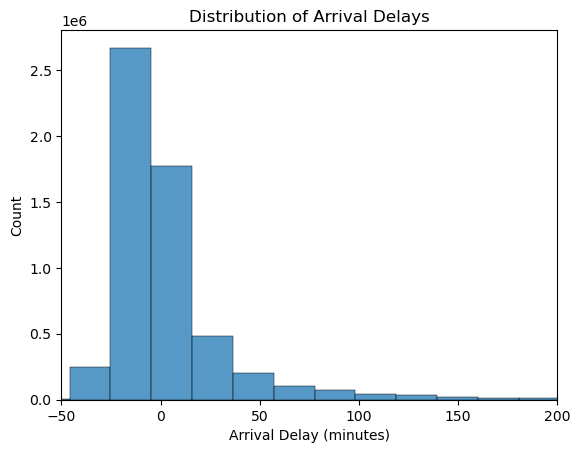

In [22]:
sns.histplot(flights["ARRIVAL_DELAY"], bins=100)
plt.xlim(-50, 200)
plt.title("Distribution of Arrival Delays")
plt.xlabel("Arrival Delay (minutes)")
plt.show()

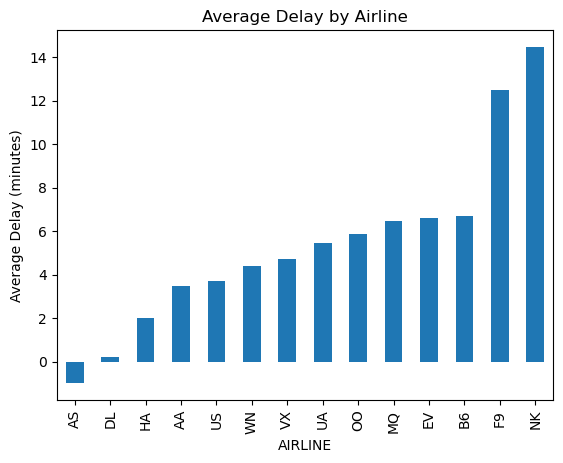

In [25]:
delay_by_airline = flights.groupby("AIRLINE")["ARRIVAL_DELAY"].mean().sort_values()

delay_by_airline.plot(kind="bar")
plt.title("Average Delay by Airline")
plt.ylabel("Average Delay (minutes)")
plt.show()

In [ ]:
flights

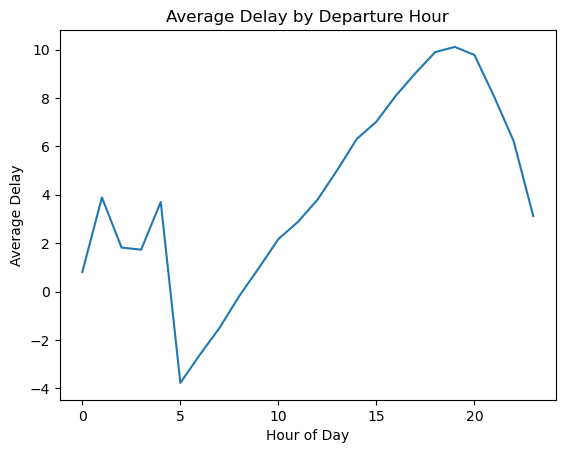

In [4]:
flights["DepHour"] = flights["SCHEDULED_DEPARTURE"] // 100

delay_by_hour = flights.groupby("DepHour")["ARRIVAL_DELAY"].mean()

delay_by_hour.plot()
plt.title("Average Delay by Departure Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Delay")
plt.show()  

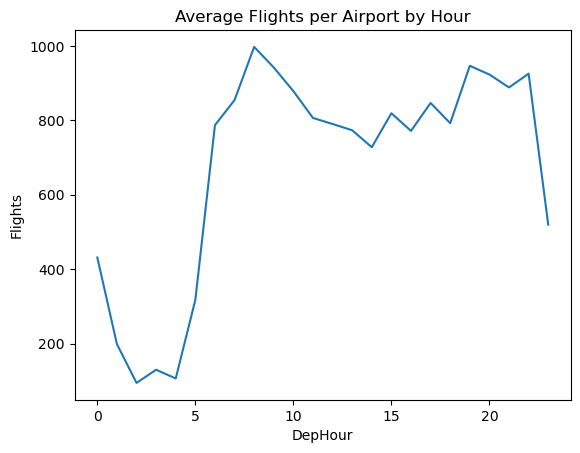

In [5]:
traffic = flights.groupby(["ORIGIN_AIRPORT","DepHour"]).size()

traffic_by_hour = traffic.groupby("DepHour").mean()

traffic_by_hour.plot()
plt.title("Average Flights per Airport by Hour")
plt.ylabel("Flights")
plt.show()  

In [7]:
flights["on_time"] = flights["ARRIVAL_DELAY"] <= 10

route_reliability = (
    flights.groupby(["ORIGIN_AIRPORT","DESTINATION_AIRPORT"])["on_time"]
    .mean()
    .sort_values()
)

print(route_reliability.head(10))

ORIGIN_AIRPORT  DESTINATION_AIRPORT
MSN             BOS                    0.0
TYS             LEX                    0.0
IAD             DAY                    0.0
MDT             DEN                    0.0
RDU             PHF                    0.0
ORD             GJT                    0.0
11423           11433                  0.0
                13487                  0.0
12892           11884                  0.0
14843           12264                  0.0
Name: on_time, dtype: float64


## Intermediate

## Advanced